In [40]:
import torch
import torch.nn.functional as F
# Load the SD2 encoder / Text tokenizer, encoder
from transformers import CLIPTextModel, CLIPTokenizer
from diffusers import (
    AutoencoderKL,
    DDIMScheduler,
    UNet2DConditionModel,
)
from typing import Literal, Optional

from torchvision import transforms

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import decord

In [3]:
split_caption = [
    "Drive on road",
    "Avoid the road",
    "Avoid the stairs",
    "Drive on stairs"
]
sim_matrix = clip_pairwise_cosine(split_caption)
print(sim_matrix.round(decimals=3))

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

tensor([[1.0000, 0.9280, 0.7830, 0.8260],
        [0.9280, 1.0000, 0.8680, 0.7950],
        [0.7830, 0.8680, 1.0000, 0.9110],
        [0.8260, 0.7950, 0.9110, 1.0000]])


In [37]:
device = "cuda"
pretrained_model = "stabilityai/stable-diffusion-2"

text_tokenizer = CLIPTokenizer.from_pretrained(pretrained_model, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(pretrained_model, subfolder="text_encoder")
text_encoder.eval()  # Set to evaluation model
text_encoder.to(device)

image_encoder = AutoencoderKL.from_pretrained(pretrained_model, subfolder="vae")
image_encoder.eval()  # Set to evaluation model
image_encoder.to(device)

unet = UNet2DConditionModel.from_pretrained(pretrained_model, subfolder="unet")
unet.enable_xformers_memory_efficient_attention()
unet.eval()  # Set to evaluation model
unet.to(device)

scheduler = DDIMScheduler.from_pretrained(pretrained_model, subfolder="scheduler")

Number of frames: (1, 480, 640, 3)


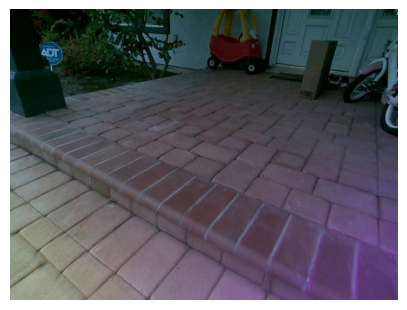

In [38]:
%matplotlib inline
# Load the image 
PROJECT_DIR = "/home/ubuntu/playground/spinflow"
SUB_DIR = "data/fai_raw/output_rides_2025-04-17-14-59-00/ride_ferrite1_2025-04-17-15-01-24_0"
START_FRAME = 670
END_FRAME = START_FRAME + 1

video_path = Path(PROJECT_DIR) / SUB_DIR / "front_camera.mp4"
video_reader = decord.VideoReader(str(video_path))
video_np = video_reader.get_batch(range(START_FRAME, END_FRAME)).asnumpy()

print(f"Number of frames: {video_np.shape}")

# Plot first image frame
plt.figure(figsize=(5, 5))
plt.imshow(video_np[0])
plt.axis('off')
plt.show()

In [ ]:
def encode_text(texts, tokenizer, encoder):
    """
    Encodes a list of text prompts using the CLIP tokenizer and encoder.
    """
    text_tokens = tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=tokenizer.model_max_length,
        return_tensors="pt"
    )
    text_tokens = {k: v.to(text_encoder.device) for k, v in text_tokens.items()}
    out = encoder(**text_tokens)
    return out.last_hidden_state.float()

def encode_image(images, feature_extractor, latent_scale_factor=0.18215):
    h = feature_extractor.encoder(images)
    moments = feature_extractor.quant_conv(h)
    mean, logvar = torch.chunk(moments, 2, dim=1)

    rgb_latent = mean * latent_scale_factor
    return rgb_latent

def preprocess_images(image, range=(-1, 1)):
    """Convert the image to tensor and normalize it"""
    imgs_f32 = image.astype(np.float32) / 255.0

    # 2) NUMPY  -->  TORCH  &  channel-first
    imgs_th = torch.from_numpy(imgs_f32).permute(0, 3, 1, 2)  # (B,3,H,W)

    # 3) [0, 1]  -->  [-1, 1]
    imgs_th = imgs_th * (range[1] - range[0]) + range[0]

    return imgs_th

@torch.no_grad()
def patch_token_similarity(
    img_latent: torch.Tensor,    # (B, C_img, H, W)  —  latents from VAE.encode().latent_dist.sample()
    txt_latent: torch.Tensor,    # (B, L, C_txt)     —  hidden_states from text_encoder
    attn_block,     # U-Net block that defines the shared proj
    normalise: bool = True,
    return_map: Literal["flat", "spatial"] = "spatial",
) -> torch.Tensor:
    """
    Cosine-similarity  (B, H*W, L)  between every image patch and every text token.

    Parameters
    ----------
    img_latent : sampled latent *z* (NOT ε), shape (B, C_img, H, W)
    txt_latent : hidden_states from CLIP text encoder, shape (B, L, C_txt)
    attn_block : unet.mid_block.attentions[0] by default
    normalise  : if True, L2-normalise before dot-product  ⇒  cosine sim in [-1,1]
    return_map : "spatial" →  (B, L, H, W)   ("flat" →  (B, H*W, L))

    Returns
    -------
    sim : torch.Tensor
        Cos-sim matrix.  By default (B, L, H, W) so you can visualise a heat-map
        per token.  Use `return_map="flat"` if you want the raw (B, HW, L).
    """
    B, C, H, W = img_latent.shape
    HW         = H * W
    import pdb; pdb.set_trace()  # Debugging line to inspect NaNs
    # -- project with SAME Linear layers the U-Net uses -------------------
    img_flat = img_latent.flatten(2).permute(0, 2, 1)       # (B, HW, C_img)
    img_k    = attn_block.to_k(img_flat)                    # (B, HW, d)
    txt_q    = attn_block.to_q(txt_latent)                  # (B,  L,  d)

    if normalise:
        img_k = F.normalize(img_k, dim=-1)
        txt_q = F.normalize(txt_q, dim=-1)

    # -- cosine similarity -----------------------------------------------
    #   (B, HW, d)  · (B, d, L)  →  (B, HW, L)
    sim_flat = torch.einsum('bnd,bdm->bnm', img_k, txt_q.transpose(-1, -2))

    if return_map == "flat":
        return sim_flat                                     # (B, HW, L)
    else:                       # reshape to (B, L, H, W) for easier viz
        return sim_flat.permute(0, 2, 1).reshape(B, txt_q.size(1), H, W)

In [44]:
CAPTION_LIST = [
    "toy car",
    "package",
    "bike"
]
imgs_th = preprocess_images(video_np)
imgs_th = imgs_th.to(device)

# Encode images and text prompts
image_latents = encode_image(imgs_th, image_encoder)
text_latents = encode_text(CAPTION_LIST, text_tokenizer, text_encoder)

# Grab middle attention block (highest semantic similarity)
attn_block = unet.mid_block.attentions[0]

print(f"Image latents shape: {image_latents.shape}")
print(f"Text latents shape: {text_latents.shape}")

sim_map = patch_token_similarity(image_latents, text_latents, attn_block)   # (1, L, H, W)

Image latents shape: torch.Size([1, 4, 60, 80])
Text latents shape: torch.Size([3, 77, 1024])
> /tmp/ipykernel_3472072/3482513064.py(65)patch_token_similarity()
     63     import pdb; pdb.set_trace()  # Debugging line to inspect NaNs
     64     # -- project with SAME Linear layers the U-Net uses -------------------
---> 65     img_flat = img_latent.flatten(2).permute(0, 2, 1)       # (B, HW, C_img)
     66     img_k    = attn_block.to_k(img_flat)                    # (B, HW, d)
     67     txt_q    = attn_block.to_q(txt_latent)                  # (B,  L,  d)

> /tmp/ipykernel_3472072/3482513064.py(66)patch_token_similarity()
     64     # -- project with SAME Linear layers the U-Net uses -------------------
     65     img_flat = img_latent.flatten(2).permute(0, 2, 1)       # (B, HW, C_img)
---> 66     img_k    = attn_block.to_k(img_flat)                    # (B, HW, d)
     67     txt_q    = attn_block.to_q(txt_latent)                  # (B,  L,  d)
     68 

Transformer2DModel(
  (